In [120]:
import pandas as pd
import pathlib as pl
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [121]:
root_path = pl.Path.cwd().parent
data_path = root_path / "data" 

In [122]:
data = pd.read_csv(data_path /"Intermed" / "googleplaystore_clean.csv")
review_data = pd.read_csv(data_path /"intermed" / "googleplaystore_user_reviews_clean.csv")

In [123]:
data.head()

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,10000.0,Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000.0,Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,5000000.0,Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,50000000.0,Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,100000.0,Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [124]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10358 entries, 0 to 10357
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      10358 non-null  int64  
 1   App             10358 non-null  str    
 2   Category        10358 non-null  str    
 3   Rating          8893 non-null   float64
 4   Reviews         10358 non-null  str    
 5   Size            10358 non-null  str    
 6   Installs        10357 non-null  float64
 7   Type            10357 non-null  str    
 8   Price           10358 non-null  str    
 9   Content Rating  10357 non-null  str    
 10  Genres          10358 non-null  str    
 11  Last Updated    10358 non-null  str    
 12  Current Ver     10350 non-null  str    
 13  Android Ver     10355 non-null  str    
dtypes: float64(2), int64(1), str(11)
memory usage: 1.1 MB


In [125]:
display(review_data.info())
display(review_data.head())

<class 'pandas.DataFrame'>
RangeIndex: 29692 entries, 0 to 29691
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     29692 non-null  str    
 1   Translated_Review       29692 non-null  str    
 2   Sentiment               29692 non-null  str    
 3   Sentiment_Polarity      29692 non-null  float64
 4   Sentiment_Subjectivity  29692 non-null  float64
dtypes: float64(2), str(3)
memory usage: 1.1 MB


None

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
3,10 Best Foods for You,Best idea us,Positive,1.00,0.300000
4,10 Best Foods for You,Best way,Positive,1.00,0.300000


# Question 2
## “Should we charge for it?”
“Everyone keeps saying ‘just make it free,’ but I want to see the data. Do paid apps actually get worse reviews, or is that just an assumption? And if we charge, is there a price point where people start pushing back? I’ve also heard that in some niches, people expect to pay — if that’s true, I want to know which ones.”



### Lidando com coluna "Price"

In [126]:
data = data[data.Price != "Everyone"]
data.Price = data.Price.str.replace("$","")
data["Price"] = pd.to_numeric(data["Price"],errors="coerce")

In [127]:
data.Price.describe()

count    10357.000000
mean         1.030800
std         16.278625
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        400.000000
Name: Price, dtype: float64

In [128]:
data["Paid"] = data.Price == 0
data["Paid"].value_counts()


Paid
True     9592
False     765
Name: count, dtype: int64

In [129]:
data["Paid"] = data["Paid"].astype(str).str.replace("True", "Free").str.replace("False", "Paid")


In [130]:
notas_free = data[data['Paid'] == 'Free']['Rating'].dropna()
notas_paid = data[data['Paid'] == 'Paid']['Rating'].dropna()

In [131]:
import scipy.stats as stats

# ... (seu código de separação das notas) ...

# --- PASSO 1: Testar a igualdade de variância (Levene) ---
stat_levene, p_levene = stats.levene(notas_free, notas_paid)
print(f"P-value do teste de Levene: {p_levene:.4f}")

# --- PASSO 2: Executar o Teste T adequado ---
if p_levene > 0.05:
    print("Variâncias Iguais: Usando Teste T de Student padrão.")
    t_stat, p_final = stats.ttest_ind(notas_paid, notas_free, equal_var=True, alternative='greater')
    df = len(notas_paid) + len(notas_free) - 2
else:
    print("Variâncias Diferentes: Usando Teste t de Welch.")
    # Adicionado 'alternative' aqui também para manter a consistência
    t_stat, p_final = stats.ttest_ind(notas_paid, notas_free, equal_var=False, alternative='greater')
    
    # Cálculo aproximado dos graus de liberdade para Welch (opcional para o print)
    v1, v2 = notas_paid.var(), notas_free.var()
    n1, n2 = len(notas_paid), len(notas_free)
    df = (v1/n1 + v2/n2)**2 / ((v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1))

# --- PASSO 3: Valor Crítico (O "muro" do gráfico) ---
# Encontra o valor de t para 5% de significância (unilateral)
t_critico = stats.t.ppf(1 - 0.05, df)

print("-" * 30)
print(f"Estatística t calculada: {t_stat:.4f}")
print(f"Valor Crítico t (limite): {t_critico:.4f}")
print(f"P-value Final: {p_final:.4f}")
print("-" * 30)

if t_stat > t_critico:
    print("A estatística t caiu na REGIÃO DE REJEIÇÃO.")
    print("Conclusão: Apps pagos têm avaliações significativamente maiores.")
else:
    print("A estatística t caiu na REGIÃO DE ACEITAÇÃO.")
    print("Conclusão: Não há evidências de que apps pagos avaliam melhor.")

P-value do teste de Levene: 0.2312
Variâncias Iguais: Usando Teste T de Student padrão.
------------------------------
Estatística t calculada: 3.6189
Valor Crítico t (limite): 1.6450
P-value Final: 0.0001
------------------------------
A estatística t caiu na REGIÃO DE REJEIÇÃO.
Conclusão: Apps pagos têm avaliações significativamente maiores.


/var/folders/cq/5nd0n3jx7zlbj9vw7ljftrpc0000gn/T/ipykernel_28106/977226844.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Paid', y='Rating', width=0.5, ax=ax[0], palette='Set2')


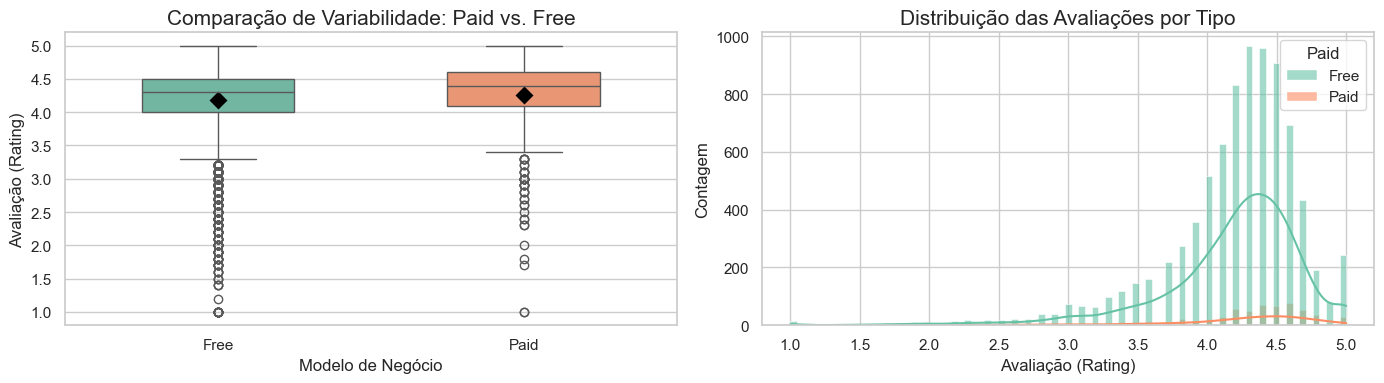

In [132]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4)) # Aumentei um pouco a altura para não cortar títulos
sns.set_theme(style="whitegrid")

# --- GRÁFICO 1: Boxplot ---
sns.boxplot(data=data, x='Paid', y='Rating', width=0.5, ax=ax[0], palette='Set2')
sns.pointplot(data=data, x='Paid', y='Rating', color='black', 
              markers='D', linestyles='', errorbar=None, ax=ax[0])

# Configurações específicas do ax[0]
ax[0].set_title('Comparação de Variabilidade: Paid vs. Free', fontsize=15)
ax[0].set_xlabel('Modelo de Negócio', fontsize=12)
ax[0].set_ylabel('Avaliação (Rating)', fontsize=12)


# --- GRÁFICO 2: Histplot ---
sns.histplot(data=data, x='Rating', hue='Paid', kde=True, palette='Set2', ax=ax[1], alpha=0.6)

# Configurações específicas do ax[1]
ax[1].set_title('Distribuição das Avaliações por Tipo', fontsize=15)
ax[1].set_xlabel('Avaliação (Rating)', fontsize=12)
ax[1].set_ylabel('Contagem', fontsize=12)

# Ajuste automático para evitar sobreposição de elementos
plt.tight_layout()
plt.show()

### Tratando Dataset de Reviews

In [133]:
review_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 29692 entries, 0 to 29691
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     29692 non-null  str    
 1   Translated_Review       29692 non-null  str    
 2   Sentiment               29692 non-null  str    
 3   Sentiment_Polarity      29692 non-null  float64
 4   Sentiment_Subjectivity  29692 non-null  float64
dtypes: float64(2), str(3)
memory usage: 1.1 MB


In [134]:
grouped_review_data = review_data.groupby(["App"]).agg({"Sentiment_Polarity":"mean"}).sort_values("Sentiment_Polarity",ascending=False)

grouped_review_data = grouped_review_data.rename(columns={"Sentiment_Polarity":"Mean_Sentiment_Polarity"})
grouped_review_data.head()

,Mean_Sentiment_Polarity
App,
HomeWork,1.000000
Google Slides,0.933333
Daily Workouts - Exercise Fitness Routine Trainer,0.800000
Bed Time Fan - White Noise Sleep Sounds,0.781250
Cameringo Lite. Filters Camera,0.770269


In [135]:
merged_data = pd.merge(data, grouped_review_data, on="App", how="left")
merged_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10357 entries, 0 to 10356
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               10357 non-null  int64  
 1   App                      10357 non-null  str    
 2   Category                 10357 non-null  str    
 3   Rating                   8892 non-null   float64
 4   Reviews                  10357 non-null  str    
 5   Size                     10357 non-null  str    
 6   Installs                 10357 non-null  float64
 7   Type                     10356 non-null  str    
 8   Price                    10357 non-null  float64
 9   Content Rating           10357 non-null  str    
 10  Genres                   10357 non-null  str    
 11  Last Updated             10357 non-null  str    
 12  Current Ver              10349 non-null  str    
 13  Android Ver              10355 non-null  str    
 14  Paid                     10357 no

In [136]:
print(merged_data[merged_data['Paid'] == 'Paid']['Mean_Sentiment_Polarity'].notna().sum())
print(merged_data[merged_data['Paid'] == 'Free']['Mean_Sentiment_Polarity'].notna().sum())

11
1068


In [137]:


sentimento_free = merged_data[merged_data['Paid'] == 'Free']['Mean_Sentiment_Polarity'].dropna()
sentimento_paid = merged_data[merged_data['Paid'] == 'Paid']['Mean_Sentiment_Polarity'].dropna()

# 2. Teste de Levene (Variância)
stat, p_levene = stats.levene(sentimento_free, sentimento_paid)
print(f"P-value Levene (Sentimento): {p_levene}")

# 3. Teste T (Ajustado pela variância)
t_stat, p_final = stats.ttest_ind(sentimento_free, sentimento_paid, equal_var=(p_levene > 0.05))

print(f"P-value Final (Sentimento): {p_final}")

P-value Levene (Sentimento): 0.1535076846456471
P-value Final (Sentimento): 0.8872558467339734


In [138]:
resume = merged_data.groupby(["Paid"]).agg({
    "Mean_Sentiment_Polarity":"mean",
    "Rating":"mean",
    "App":"count"
    }).rename(columns={
        "App": "Total Apps",
        "Rating": "Mean_Rating"
        }).sort_values("Mean_Sentiment_Polarity",ascending=False)
display(resume.head())

merged_data_sentiment = merged_data[merged_data.Mean_Sentiment_Polarity.notna()]
merged_data_sentiment.groupby("Paid").agg({"Mean_Sentiment_Polarity":"count"}).rename(columns={"Mean_Sentiment_Polarity":"Count_Of_Mean_Sentiment_Polarity"})


,Mean_Sentiment_Polarity,Mean_Rating,Total Apps
Paid,,,
Free,0.185482,4.182425,9592
Paid,0.178744,4.261501,765


,Count_Of_Mean_Sentiment_Polarity
Paid,
Free,1068
Paid,11


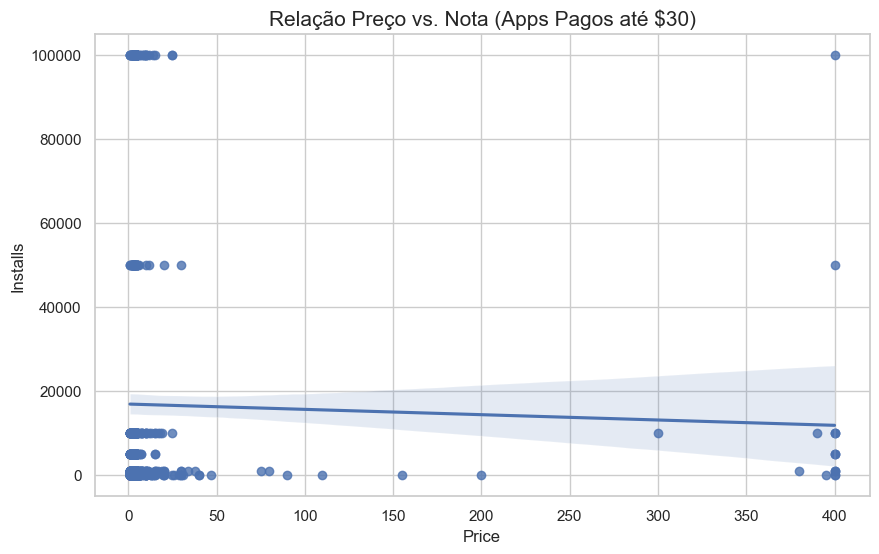

In [139]:
# Cada condição entre () e unidas por &
data_normal_price = data[(data['Installs'] < 500000) & (data['Paid'] == 'Paid')]

plt.figure(figsize=(10, 6))
sns.regplot(data=data_normal_price, x="Price", y="Installs")

plt.title('Relação Preço vs. Nota (Apps Pagos até $30)', fontsize=15)
plt.show()

In [ ]:
category_paid_data = data.groupby(["Category","Paid"]).agg({
    "Installs":"sum"
})

df_exploded = data.copy()

# Transformamos a string 'Genero1;Genero2' em uma lista ['Genero1', 'Genero2']
df_exploded['Genres'] = df_exploded['Genres'].astype(str).str.split(';')

# "Explodimos" a lista: o que era uma linha vira duas ou mais, uma para cada gênero
df_exploded = df_exploded.explode('Genres')



Genres_paid_data= df_exploded.groupby(["Genres","Paid"]).agg({
    "Installs":"sum"
})

/var/folders/cq/5nd0n3jx7zlbj9vw7ljftrpc0000gn/T/ipykernel_28106/676279835.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cat['Share_Paid'], y=top_cat.index, palette='magma', ax=ax[0])
/var/folders/cq/5nd0n3jx7zlbj9vw7ljftrpc0000gn/T/ipykernel_28106/676279835.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_gen['Share_Paid'], y=top_gen.index, palette='magma', ax=ax[1])


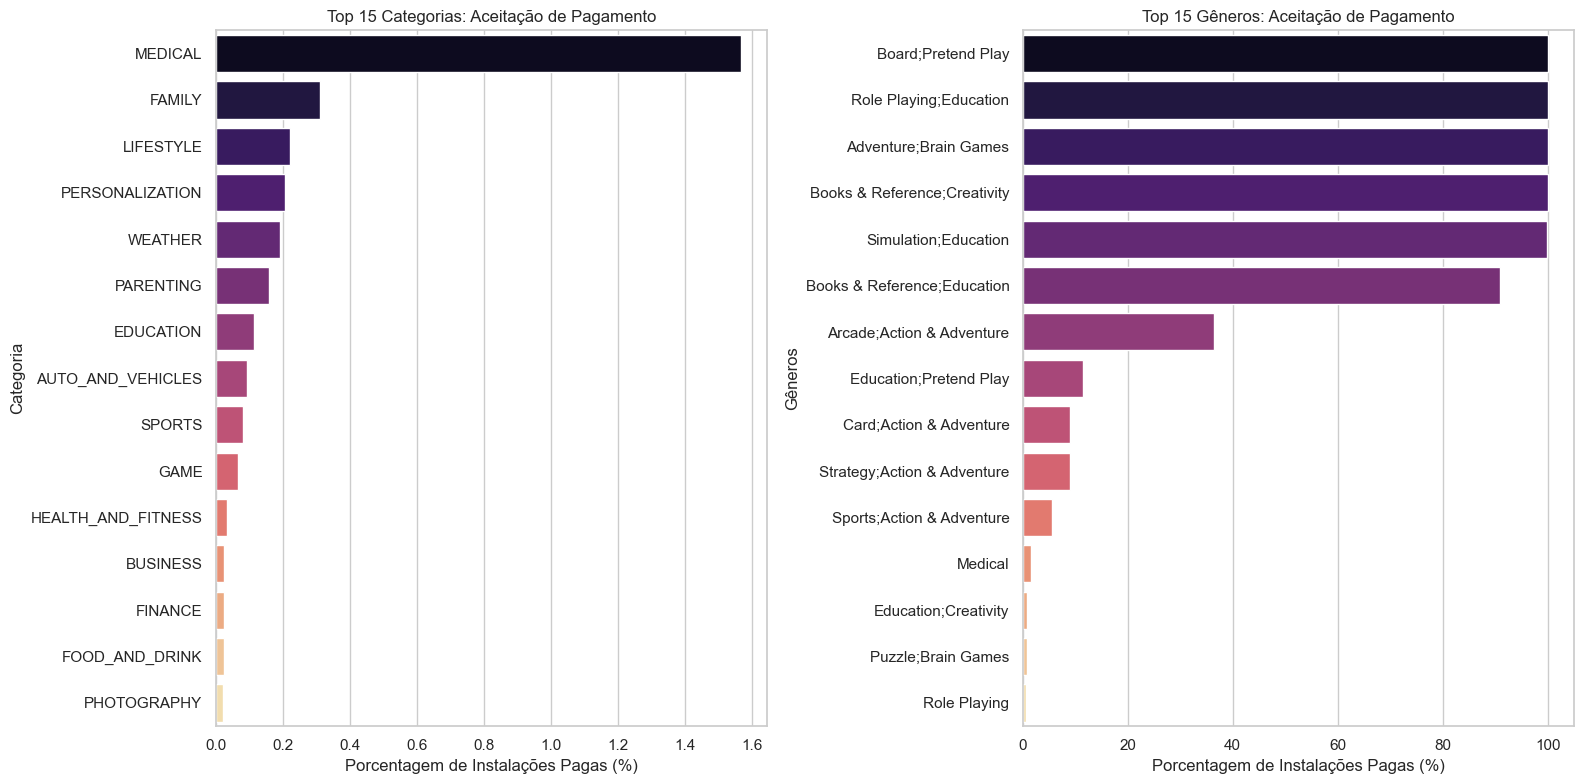

In [145]:

# 1. Criar a figura com 2 colunas
fig, ax = plt.subplots(1, 2, figsize=(16, 8)) # Aumentei um pouco o figsize para caber melhor

# --- LÓGICA PARA CATEGORIAS (AX 0) ---
pivot_cat = category_paid_data.reset_index().pivot(index='Category', columns='Paid', values='Installs').fillna(0)
pivot_cat['Total'] = pivot_cat['Free'] + pivot_cat['Paid']
pivot_cat['Share_Paid'] = (pivot_cat['Paid'] / pivot_cat['Total']) * 100
top_cat = pivot_cat.sort_values('Share_Paid', ascending=False).head(15)

sns.barplot(x=top_cat['Share_Paid'], y=top_cat.index, palette='magma', ax=ax[0])
ax[0].set_title('Top 15 Categorias: Aceitação de Pagamento', fontsize=12) # Use set_title
ax[0].set_xlabel('Porcentagem de Instalações Pagas (%)')
ax[0].set_ylabel('Categoria')

# --- LÓGICA PARA GÊNEROS (AX 1) ---
pivot_gen = Genres_paid_data.reset_index().pivot(index='Genres', columns='Paid', values='Installs').fillna(0)
pivot_gen['Total'] = pivot_gen['Free'] + pivot_gen['Paid']
pivot_gen['Share_Paid'] = (pivot_gen['Paid'] / pivot_gen['Total']) * 100
top_gen = pivot_gen.sort_values('Share_Paid', ascending=False).head(15)

sns.barplot(x=top_gen['Share_Paid'], y=top_gen.index, palette='magma', ax=ax[1])
ax[1].set_title('Top 15 Gêneros: Aceitação de Pagamento', fontsize=12) # Use set_title
ax[1].set_xlabel('Porcentagem de Instalações Pagas (%)')
ax[1].set_ylabel('Gêneros')

# --- AJUSTES FINAIS DA FIGURA ---
plt.tight_layout() # Chamado na figura completa
plt.show() # Chamado apenas uma vez ao final

In [142]:
data["Content Rating"].value_counts()

Content Rating
Everyone           8382
Teen               1146
Mature 17+          447
Everyone 10+        377
Adults only 18+       3
Unrated               2
Name: count, dtype: int64

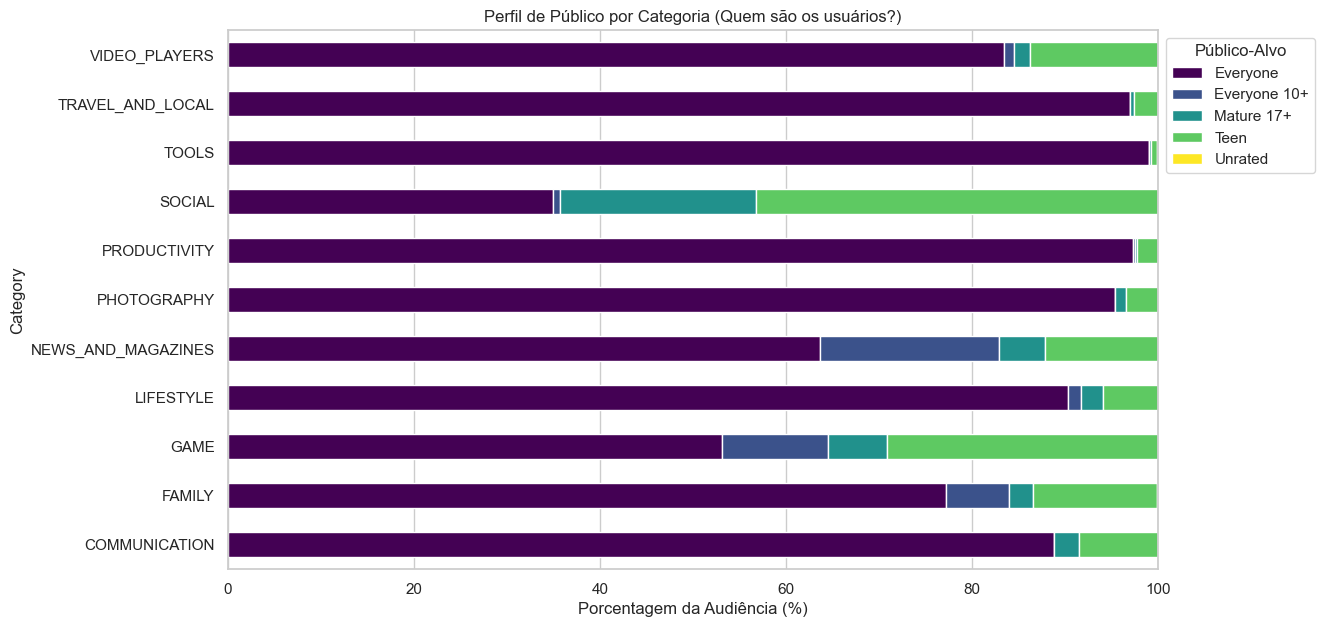

In [143]:
# Filtrando as top 10 categorias em downloads para comparar
top_cats = data.groupby('Category')['Installs'].sum().nlargest(10).index
subset = data[(data['Category'].isin(top_cats)) | (data["Category"].isin(["LIFESTYLE","PRETEND PLAY"]))]

# Criando uma tabela cruzada de Categoria vs Público
ct = pd.crosstab(subset['Category'], subset['Content Rating'], normalize='index') * 100

# Plotando
ct.plot(kind='barh', stacked=True, figsize=(12, 7), colormap='viridis')
plt.title('Perfil de Público por Categoria (Quem são os usuários?)')
plt.xlabel('Porcentagem da Audiência (%)')
plt.legend(title='Público-Alvo', bbox_to_anchor=(1, 1))
plt.show()